<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
from matplotlib.lines import Line2D
from plant_hydraulics.utils import satvap
from plant_hydraulics.root_parms import root_params
from plant_hydraulics.soil_params import soil_params
from plant_hydraulics.leaf_fluxes import leaf_fluxes
from plant_hydraulics.soil_resistance import soil_resistance
from plant_hydraulics.leaf_phys_params import leaf_phys_params
from plant_hydraulics.parameter_classes import (
    PhysCon,
    Params,
    Ground,
    Soil,
    RootVar,
    Leaf,
    Flux,
    Atmos,
)

from plant_hydraulics.utils import diurnal_temperature, diurnal_par, diurnal_relhum

## 1. Set up soil and plant (time-invariant parts)

In [ ]:
def setup_plant_and_soil():
    # General params ------------------------------------------------------------
    params = Params()
    physcon = PhysCon()

    # Root params ---------------------------------------------------------------
    rootvar = RootVar()
    rootvar = root_params(rootvar)

    # Soil params ---------------------------------------------------------------
    soil = Soil()

    # Loam
    soil.texture = 5
    soil = soil_params(soil)

    soil_frac = 0.50
    for each_soil_layer in range(soil.nlevsoi):
        vol = soil_frac * soil.watsat[each_soil_layer]
        soil.h2osoi_vol.append(vol)
        soil.psi.append(
            soil.psisat[each_soil_layer]
            * (vol / soil.watsat[each_soil_layer]) ** (-soil.bsw[each_soil_layer])
        )

    # Leaf params ---------------------------------------------------------------
    leaf = Leaf()
    leaf.c3psn = 1
    leaf.colim = 1
    leaf = leaf_phys_params(params, physcon, leaf)

    # Flux params ---------------------------------------------------------------
    flux = Flux()
    flux.height = 15.0
    rootvar.biomass = 500.0
    flux.lai = 5.0

    flux.rplant = 1.0 / leaf.gplant
    flux = soil_resistance(physcon, leaf, rootvar, soil, flux)
    flux.lsc = 1.0 / (flux.rsoil + flux.rplant)

    # Timestep = 30 minutes
    flux.dt = 30.0 * 60.0  # seconds

    return params, physcon, leaf, flux

### Set up plant and soil objects

In [ ]:
pprint(setup_plant_and_soil())

(Params(vis=0, nir=1),
 PhysCon(grav=9.80665,
         tfrz=273.15,
         sigma=5.67e-08,
         mmdry=0.02897,
         mmh2o=0.01802,
         cpd=1005.0,
         cpw=1846.0,
         rgas=8.31446,
         visc0=1.33e-05,
         Dh0=1.89e-05,
         Dv0=2.18e-05,
         Dc0=1.38e-05,
         denh2o=1000.0),
 Leaf(c3psn=1,
      colim=1,
      vcmax25=60.0,
      jmax25=100.19999999999999,
      rd25=0.8999999999999999,
      kc25=404.9,
      ko25=278.4,
      cp25=42.75,
      kcha=79430.0,
      koha=36380.0,
      cpha=37830.0,
      vcmaxha=65330.0,
      jmaxha=43540.0,
      rdha=46390.0,
      vcmaxhd=150000.0,
      jmaxhd=150000.0,
      rdhd=150000.0,
      vcmaxse=490.0,
      jmaxse=490.0,
      rdse=490.0,
      vcmaxc=np.float64(1.2068286010531608),
      jmaxc=np.float64(1.2068286010531608),
      rdc=np.float64(1.2068286010531608),
      phi_psii=0.85,
      theta_j=0.9,
      colim_c3=0.98,
      colim_c4a=0.8,
      colim_c4b=0.95,
      qe_c4=0.05,
  

In [ ]:
params, physcon, leaf, flux_template = setup_plant_and_soil()

## 2. Set up atmosphere

In [ ]:
def update_atmosphere(physcon, params, leaf, flux, hour):
    """
    Update atmospheric forcing for a given hour of the day.

    This is called at each timestep to set the time-varying boundary
    conditions: temperature, humidity, radiation.

    IMPORTANT: This modifies flux IN PLACE for radiation terms,
    and returns a new atmos object.
    """
    atmos = Atmos()

    # Constants -----------------------------------------------------------------

    # m/s
    atmos.wind = 1.0

    # Pa
    atmos.patm = 101325.0

    # µmol/mol
    atmos.co2air = 380.0

    # mmol/mol
    atmos.o2air = 209.0

    # Time-varying forcing ------------------------------------------------------
    tair_c = diurnal_temperature(hour)
    relhum = diurnal_relhum(hour)

    # W/m² total shortwave
    fsds = diurnal_par(hour)

    # K
    atmos.tair = physcon.tfrz + tair_c
    atmos.relhum = relhum

    # Vapor pressure from T and RH
    esat_air, _ = satvap(tair_c)
    atmos.eair = esat_air * (relhum / 100.0)

    # Derived atmospheric properties --------------------------------------------
    atmos.rhomol = atmos.patm / (physcon.rgas * atmos.tair)
    atmos.qair = (
        physcon.mmh2o
        / physcon.mmdry
        * atmos.eair
        / (atmos.patm - (1 - physcon.mmh2o / physcon.mmdry) * atmos.eair)
    )
    atmos.rhoair = (
        atmos.rhomol
        * physcon.mmdry
        * (1 - (1 - physcon.mmh2o / physcon.mmdry) * atmos.eair / atmos.patm)
    )
    atmos.mmair = atmos.rhoair / atmos.rhomol
    atmos.cpair = (
        physcon.cpd * (1 + (physcon.cpw / physcon.cpd - 1) * atmos.qair) * atmos.mmair
    )

    # Longwave sky radiation, varies with temperature ---------------------------

    # Simple approximation: clear-sky emissivity ≈ 0.7 + small T correction
    atmos.irsky = 0.70 * physcon.sigma * atmos.tair**4

    # Radiation absorbed by leaf ------------------------------------------------

    # VIS, NIR
    ground_albedo = [0.1, 0.2]

    atmos.swsky[params.vis] = 0.5 * fsds
    atmos.swsky[params.nir] = 0.5 * fsds

    tg = atmos.tair
    ground_lw = physcon.sigma * tg**4

    flux.swinc = [
        atmos.swsky[params.vis] * (1 + ground_albedo[params.vis]),
        atmos.swsky[params.nir] * (1 + ground_albedo[params.nir]),
    ]
    flux.swflx = [
        flux.swinc[0] * (1 - leaf.rho[0] - leaf.tau[0]),
        flux.swinc[1] * (1 - leaf.rho[1] - leaf.tau[1]),
    ]
    # µmol photons/m²/s
    flux.apar = flux.swflx[0] * 4.6

    flux.qa = flux.swflx[0] + flux.swflx[1] + leaf.emiss * (atmos.irsky + ground_lw)

    # Initial leaf temperature guess = air temperature
    flux.tleaf = atmos.tair

    return atmos

## 3. Time-stepping loop

In [ ]:
# Time axis: 0:00 to 23:30 in 30-min steps

# 30 minutes
dt_hours = 0.5

hours = np.arange(0.0, 24.0, dt_hours)

# 48 timesteps
n_steps = len(hours)

## 4. Define gs models and create empty objects for storing results 

In [ ]:
# Model definitions
models = {
    "optimization": {"label": "WUE Bonan", "color": "#2166ac", "marker": "o"},
    "medlyn": {"label": "Medlyn", "color": "#b2182b", "marker": "s"},
    "profit_max": {"label": "Profit-Max", "color": "#1b7837", "marker": "D"},
}

In [ ]:
# Storage for forcings (same for all models)
forcings = {
    # W/m²
    "par": np.zeros(n_steps),
    # °C
    "tair": np.zeros(n_steps),
    # %
    "rh": np.zeros(n_steps),
    # kPa
    "vpd": np.zeros(n_steps),
}

print(forcings)

{'par': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'tair': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'rh': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), 'vpd': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])}


In [ ]:
# Storage for model outputs
results = {}
for each_gs_model in models:
    results[each_gs_model] = {
        "gs": np.zeros(n_steps),
        "an": np.zeros(n_steps),
        "tleaf": np.zeros(n_steps),
        "etflx": np.zeros(n_steps),
        "psi_leaf": np.zeros(n_steps),
        "lhflx": np.zeros(n_steps),
        "gplant": np.zeros(n_steps),
    }

## 5. Create forcings 

In [ ]:
# Record forcing first (for plotting)
for each_i, hour in enumerate(hours):
    tair_c = diurnal_temperature(hour)

    rh = diurnal_relhum(hour)

    # VPD
    esat, _ = satvap(tair_c)
    forcings["vpd"][each_i] = esat * (1.0 - rh / 100.0) / 1000.0

    # PAR
    forcings["par"][each_i] = diurnal_par(hour)

    # Temperature air
    forcings["tair"][each_i] = tair_c

    # Relative humidity
    forcings["rh"][each_i] = rh

In [ ]:
print("Forcing summary:")
print(f"  Temperature: {forcings['tair'].min():.1f} - {forcings['tair'].max():.1f} °C")
print(f"  RH:          {forcings['rh'].min():.1f} - {forcings['rh'].max():.1f} %")
print(f"  VPD:         {forcings['vpd'].min():.2f} - {forcings['vpd'].max():.2f} kPa")
print(f"  PAR peak:    {forcings['par'].max():.0f} W/m²")

Forcing summary:
  Temperature: 18.0 - 32.0 °C
  RH:          45.0 - 85.0 %
  VPD:         0.31 - 2.62 kPa
  PAR peak:    800 W/m²


### Plot forcings

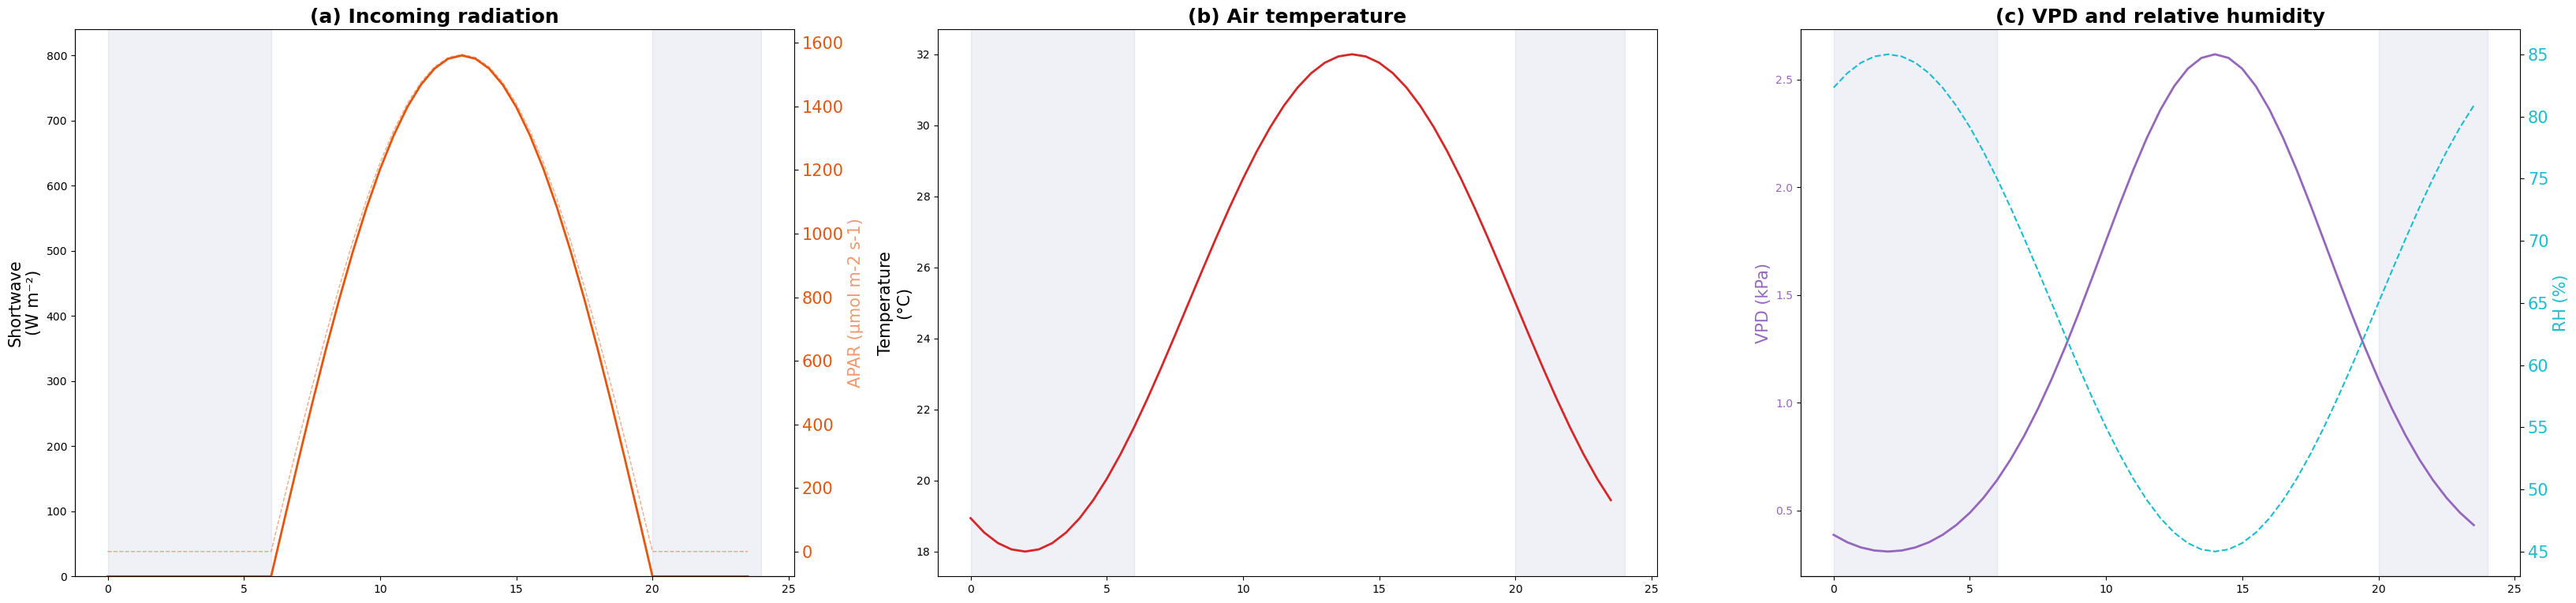

In [ ]:
# | echo: false
fig, axes = plt.subplots(1, 3, figsize=(40, 9))
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 15,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# Color for forcing panels (grey)
fc = "#555555"

# Shade nighttime (before sunrise and after sunset)
sunrise, sunset = 6.0, 20.0
for ax in axes.flat:
    ax.axvspan(0, sunrise, alpha=0.06, color="navy", zorder=0)
    ax.axvspan(sunset, 24, alpha=0.06, color="navy", zorder=0)

#  Environmental forcings -------------------------------------------------------

# Figure A
ax = axes[0]
ax.plot(hours, forcings["par"], color="#e6550d", linewidth=2)
ax.set_ylabel("Shortwave\n(W m⁻²)", fontsize=15)
ax.set_title("(a) Incoming radiation", fontweight="bold")
ax.set_ylim(bottom=0)

# Add APAR on secondary axis
ax2 = ax.twinx()
ax2.plot(
    hours,
    forcings["par"] * 0.5 * (1 - 0.1 - 0.05) * 4.6,
    color="#e6550d",
    linewidth=1,
    linestyle="--",
    alpha=0.5,
)

ax2.set_ylabel("APAR (µmol m-2 s-1)", fontsize=15, color="#e6550d", alpha=0.6)
ax2.tick_params(axis="y", labelcolor="#e6550d", labelsize=15)
ax2.spines["top"].set_visible(False)

# Figure B
ax = axes[1]
ax.plot(hours, forcings["tair"], color="#d62728", linewidth=2)
ax.set_ylabel("Temperature\n(°C)", fontsize=15)
ax.set_title("(b) Air temperature", fontweight="bold")

# Figure C
ax = axes[2]
ax.plot(hours, forcings["vpd"], color="#9467bd", linewidth=2, label="VPD")
ax.set_ylabel("VPD (kPa)", fontsize=15, color="#9467bd")

ax.tick_params(axis="y", labelcolor="#9467bd")

ax.set_title("(c) VPD and relative humidity", fontweight="bold")

# Add RH% on secondary axis
ax2 = ax.twinx()
ax2.plot(
    hours, forcings["rh"], color="#17becf", linewidth=1.5, linestyle="--", label="RH"
)
ax2.set_ylabel("RH (%)", fontsize=15, color="#17becf")
ax2.tick_params(axis="y", labelcolor="#17becf")
ax2.spines["top"].set_visible(False)

## 6. Run the models

In [ ]:
for each_model in models:
    print(f"  Running {each_model} model...", end="", flush=True)

    # Fresh flux for this model's run -------------------------------------------
    flux = copy.deepcopy(flux_template)
    leaf_m = copy.deepcopy(leaf)

    # Initial conditions at midnight --------------------------------------------
    # psi_leaf at midnight: equilibrated with soil (near psi_soil)
    # This is the predawn water potential,  Slightly below psi_soil
    flux.psi_leaf = flux.psi_soil - 0.05

    # Edit leaf model string ----------------------------------------------------
    leaf_m.stomatal_model = each_model

    # Run the model -------------------------------------------------------------
    for each_i, each_half_hour in enumerate(hours):
        # a) Update atmospheric forcing for this timestep
        atmos = update_atmosphere(physcon, params, leaf_m, flux, each_half_hour)

        # b) Run the stomatal model
        #    This internally solves:
        #    boundary layer → energy balance → photosynthesis → water potential

        #    The water potential calculation uses flux.psi_leaf (from previous
        #    timestep) and flux.dt (30 min) to compute the new psi_leaf.
        flux = leaf_fluxes(physcon, atmos, leaf_m, flux)

        # c) Store results
        results[each_model]["gs"][each_i] = flux.gs
        results[each_model]["an"][each_i] = flux.an

        # Convert from C to K
        results[each_model]["tleaf"][each_i] = flux.tleaf - physcon.tfrz

        # Convert to mmol/m²/s
        results[each_model]["etflx"][each_i] = flux.etflx * 1000
        results[each_model]["lhflx"][each_i] = flux.lhflx

        # d) psi_leaf carries over to next timestep
        #
        #    The flux object already has
        #    the updated psi_leaf from leaf_fluxes(). When the next
        #    timestep calls leaf_water_potential(), it will use this
        #    value as y0 (the "current water level in the bathtub").
        #
        #    Similarly, tleaf carries over as the initial guess for
        #    the Newton-Raphson energy balance solver.
        results[each_model]["psi_leaf"][each_i] = flux.psi_leaf

  Running optimization model...  Running medlyn model...  Running profit_max model...

### Plot model results

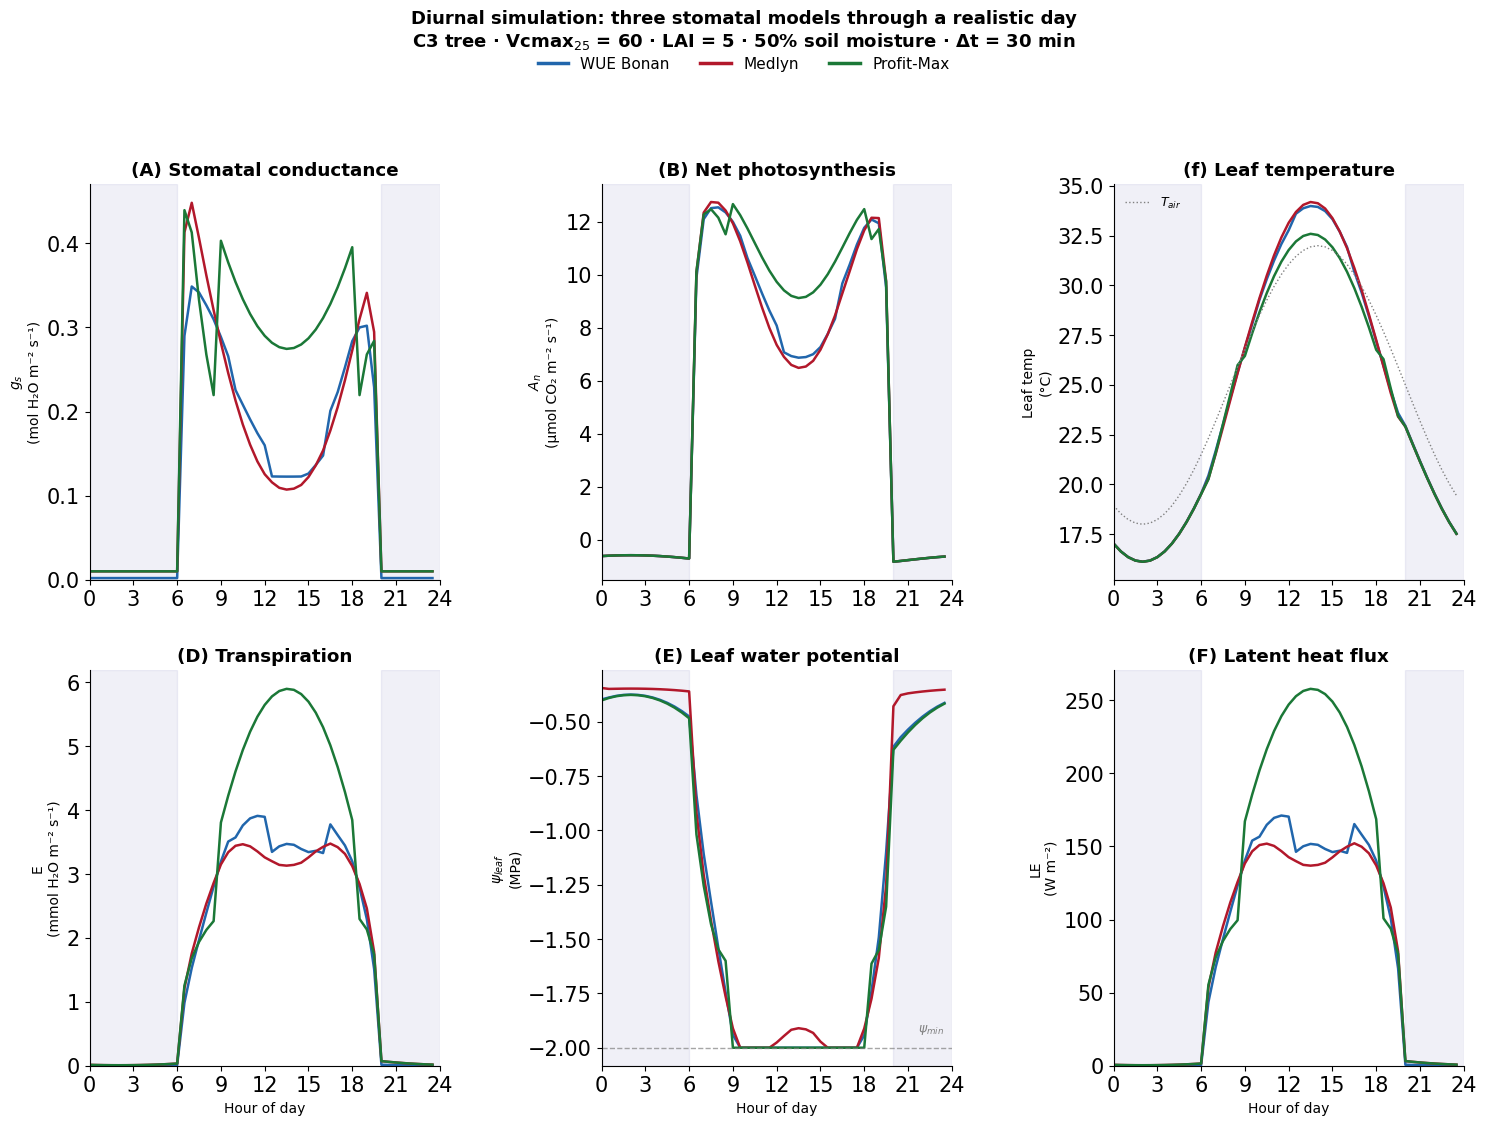

In [ ]:
# | echo: false
fig, axes = plt.subplots(2, 3, figsize=(15, 11))

# Color for forcing panels (grey)
fc = "#555555"
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.size": 11,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# Gray shade at nighttime (before sunrise and after sunset) ---------------------
sunrise, sunset = 6.0, 20.0
for ax in axes.flat:
    ax.axvspan(0, sunrise, alpha=0.06, color="navy", zorder=0)
    ax.axvspan(sunset, 24, alpha=0.06, color="navy", zorder=0)


# Gas exchange outputs ----------------------------------------------------------

# Figure A
ax = axes[0, 0]

for m, p in models.items():
    ax.plot(hours, results[m]["gs"], color=p["color"], linewidth=1.8)

ax.set_ylabel(r"$g_s$" + "\n(mol H₂O m⁻² s⁻¹)", fontsize=10)
ax.set_title("(A) Stomatal conductance", fontweight="bold")
ax.set_ylim(bottom=0)


# Figure B
ax = axes[0, 1]

for m, p in models.items():
    ax.plot(hours, results[m]["an"], color=p["color"], linewidth=1.8)

ax.set_ylabel(r"$A_n$" + "\n(µmol CO₂ m⁻² s⁻¹)", fontsize=10)
ax.set_title("(B) Net photosynthesis", fontweight="bold")

# Figure C
ax = axes[0, 2]

for m, p in models.items():
    ax.plot(hours, results[m]["tleaf"], color=p["color"], linewidth=1.8)
ax.plot(
    hours,
    forcings["tair"],
    color="gray",
    linewidth=1,
    linestyle=":",
    label=r"$T_{air}$",
)

ax.set_ylabel("Leaf temp\n(°C)", fontsize=10)
ax.set_title("(f) Leaf temperature", fontweight="bold")
ax.legend(fontsize=9, loc="upper left", frameon=False)

# Water relations ---------------------------------------------------------------

# Figure D

ax = axes[1, 0]
for m, p in models.items():
    ax.plot(hours, results[m]["etflx"], color=p["color"], linewidth=1.8)
ax.set_ylabel("E\n(mmol H₂O m⁻² s⁻¹)", fontsize=10)
ax.set_title("(D) Transpiration", fontweight="bold")
ax.set_ylim(bottom=0)

# Figure E
ax = axes[1, 1]
for m, p in models.items():
    ax.plot(hours, results[m]["psi_leaf"], color=p["color"], linewidth=1.8)
ax.axhline(y=-2.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.7)
ax.text(
    23.5,
    -2.0 + 0.05,
    r"$\psi_{min}$",
    color="gray",
    fontsize=9,
    ha="right",
    va="bottom",
)
ax.set_ylabel(r"$\psi_{leaf}$" + "\n(MPa)", fontsize=10)
ax.set_title("(E) Leaf water potential", fontweight="bold")

# Figure F
ax = axes[1, 2]
for m, p in models.items():
    ax.plot(hours, results[m]["lhflx"], color=p["color"], linewidth=1.8)
ax.set_ylabel("LE\n(W m⁻²)", fontsize=10)
ax.set_title("(F) Latent heat flux", fontweight="bold")
ax.set_ylim(bottom=0)

# Common x-axis formatting ------------------------------------------------------
for ax in axes.flat:
    ax.set_xlim(0, 24)
    ax.set_xticks([0, 3, 6, 9, 12, 15, 18, 21, 24])
    ax.set_xticklabels(["0", "3", "6", "9", "12", "15", "18", "21", "24"])
for ax in axes[1, :]:
    ax.set_xlabel("Hour of day", fontsize=10)

# Shared legend -----------------------------------------------------------------
legend_els = [
    Line2D([0], [0], color=p["color"], linewidth=2.5, label=p["label"])
    for p in models.values()
]
fig.legend(
    handles=legend_els,
    loc="upper center",
    ncol=3,
    fontsize=11,
    frameon=False,
    bbox_to_anchor=(0.5, 0.99),
)

fig.suptitle(
    "Diurnal simulation: three stomatal models through a realistic day\n"
    r"C3 tree · Vcmax$_{25}$ = 60 · LAI = 5 · 50% soil moisture · Δt = 30 min",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)

fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95], h_pad=2.5, w_pad=2.5)

plt.show()